In [4]:
# =========================
# 1. Install (run once in Colab)
# =========================
# !pip install torch torchvision matplotlib pillow -q


# =========================
# 2. Imports
# =========================
import torch
import torchvision
from torchvision import transforms as T
import matplotlib.pyplot as plt
from PIL import Image
import requests


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 90.1MB/s]


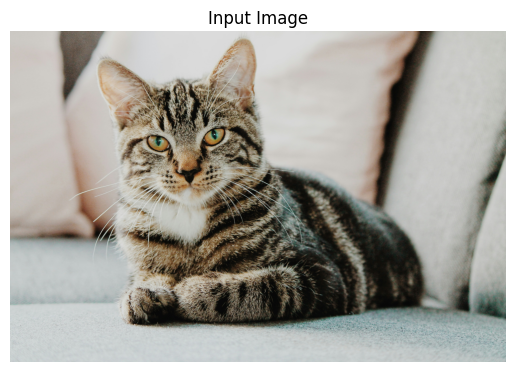

In [5]:


# =========================
# 3. Load Pretrained Mask R-CNN
# =========================
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
model.eval()


# =========================
# 4. Load Image
# =========================
url = "https://images.unsplash.com/photo-1518791841217-8f162f1e1131"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()


# =========================
# 5. Preprocess
# =========================
transform = T.Compose([T.ToTensor()])
img_tensor = transform(image)



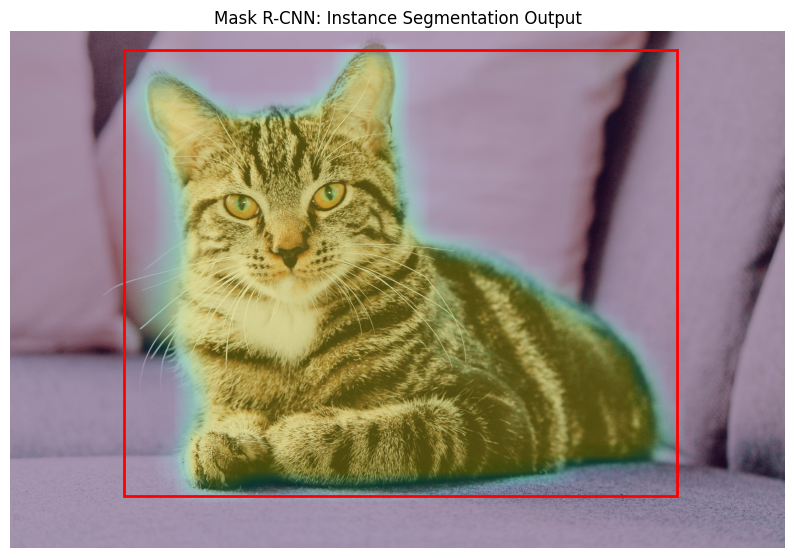

In [6]:

# =========================
# 6. Inference
# =========================
with torch.no_grad():
    prediction = model([img_tensor])


# =========================
# 7. Extract Results
# =========================
masks = prediction[0]['masks']
boxes = prediction[0]['boxes']
scores = prediction[0]['scores']

# filter weak predictions
threshold = 0.5
masks = masks[scores > threshold]
boxes = boxes[scores > threshold]


# =========================
# 8. Visualization
# =========================
plt.figure(figsize=(10,10))
plt.imshow(image)

ax = plt.gca()

for i in range(len(masks)):
    mask = masks[i, 0].mul(255).byte().cpu().numpy()

    # overlay mask
    ax.imshow(mask, alpha=0.3)

    # draw bounding box
    box = boxes[i].cpu().numpy()
    x1, y1, x2, y2 = box

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        color="red",
        linewidth=2
    )
    ax.add_patch(rect)

plt.title("Mask R-CNN: Instance Segmentation Output")
plt.axis("off")
plt.show()


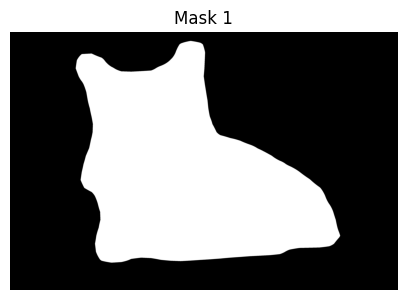

In [7]:
# =========================
# Plot masks separately
# =========================

import numpy as np
import matplotlib.pyplot as plt

num_masks = len(masks)

plt.figure(figsize=(5 * min(num_masks, 5), 5))

for i in range(min(num_masks, 5)):  # show max 5 masks
    mask = masks[i, 0].cpu().numpy()

    # convert to binary mask
    mask = mask > 0.5

    plt.subplot(1, min(num_masks, 5), i + 1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")

plt.show()
